# Ranking the observed design catalog
The available matrix contains a finite catalog of 144 observed configurations. Continuous Gaussian-process search would generate unsupported geometries and vary concentration despite the training data containing only one concentration. Since the RF is inexpensive to evaluate, this notebook exhaustively ranks observed configurations using the grouped out-of-fold predictions from notebook 03. This is a finite-catalog surrogate ranking, not Bayesian optimization.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
ROOT=Path("..").resolve()
RAW=ROOT/"data/raw"; PROC=ROOT/"data/processed/final"
FIG=ROOT/"results/final/figures"; TAB=ROOT/"results/final/tables"
for p in (PROC,FIG,TAB): p.mkdir(parents=True,exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["savefig.dpi"]=300

In [2]:
drug_names=["Ibuprofen","Lidocaine","Ascorbic acid","Estradiol","Paroxetine"]
oof=pd.read_csv(TAB/"grouped_oof_predictions.csv"); drugs=pd.read_csv(PROC/"clean_drug_data.csv")
if oof.Design_ID.nunique()!=144: print("Observed designs:",oof.Design_ID.nunique())
if oof.Concentration_pct.nunique()!=1: raise ValueError("Concentration must be fixed at the observed value.")
rank=oof[oof.Drug.isin(drug_names)].copy().sort_values(["Drug","J_Score_Normalized_OOF_Prediction"],ascending=[True,False])
rank["Rank_within_observed_designs"]=rank.groupby("Drug").cumcount()+1
rank.to_csv(TAB/"observed_design_candidate_rankings.csv",index=False,encoding="utf-8-sig")
best=rank[rank.Rank_within_observed_designs==1].copy()
best.insert(1,"MW_g_mol",best.Drug.map(drugs.set_index("Drug").MW_g_mol))
best.to_csv(TAB/"top_observed_candidate_by_drug.csv",index=False,encoding="utf-8-sig")
print("Fixed concentration:",oof.Concentration_pct.iloc[0],"%")
print("Fixed insertion speed:",oof.Insertion_speed_mm_s.iloc[0],"mm/s")
print(best.to_string(index=False))

Fixed concentration: 0.5 %
Fixed insertion speed: 5 mm/s
         Drug  MW_g_mol  Design_ID  Length_um  Base_size_um  Tip_diameter_um  Inner_diameter_um  Cone_radius_um  Density_cm2  Insertion_speed_mm_s  Concentration_pct  J_Score_Normalized_Observed  J_Score_Normalized_OOF_Prediction  Rank_within_observed_designs
Ascorbic acid    176.12        132        650           300             1.93                150            3.86          900                     5                0.5                     0.862671                           0.862671                             1
    Estradiol    272.40        132        650           300             1.93                150            3.86          900                     5                0.5                     0.693371                           0.693198                             1
    Ibuprofen    206.30        120        650           100             1.44                150            2.88          900                     5                0

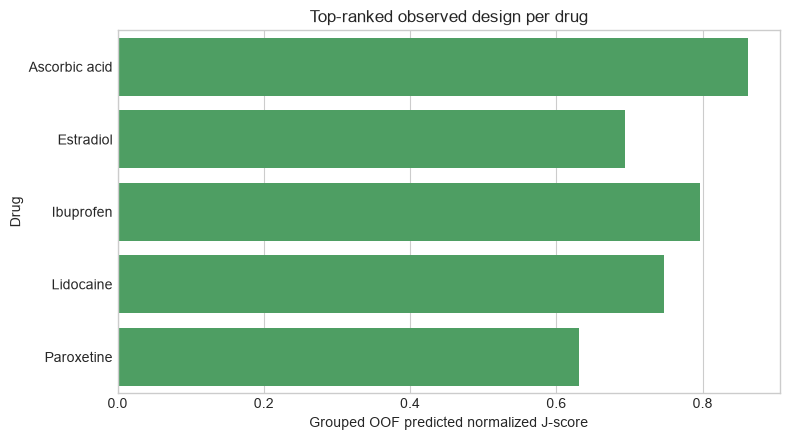

In [3]:
plt.figure(figsize=(8,4.5)); sns.barplot(data=best,x="J_Score_Normalized_OOF_Prediction",y="Drug",color="#41ab5d")
plt.xlabel("Grouped OOF predicted normalized J-score"); plt.ylabel("Drug"); plt.title("Top-ranked observed design per drug")
plt.tight_layout(); plt.savefig(FIG/"top_observed_design_candidates.png"); plt.show()

## Previously reported experimental summary
These are the five values entered as literals in the previous notebook. The available files do not include raw measurements, replicate records, or calculation provenance. This derived summary is not raw experimental data. Do not treat the listed prototype as validated by the updated observed-catalog ranking.

                  Prototype  Length_um  Inner_diameter_um  Density_cm2  Reported_gelatin_penetration_area_cm2                                               Data_status
        Needle 1 (Baseline)        600               40.0          350                                   8.50 Previously reported summary; raw measurements unavailable
      Needle 2 (Max Length)        800               40.0          350                                  10.74 Previously reported summary; raw measurements unavailable
    Needle 3 (Max Diameter)        600               60.0          350                                   1.33 Previously reported summary; raw measurements unavailable
     Needle 4 (Max Density)        600               40.0          500                                   2.62 Previously reported summary; raw measurements unavailable
Needle 5 (Candidate Design)        688               45.2          402                                   5.77 Previously reported summary; raw measurements unav

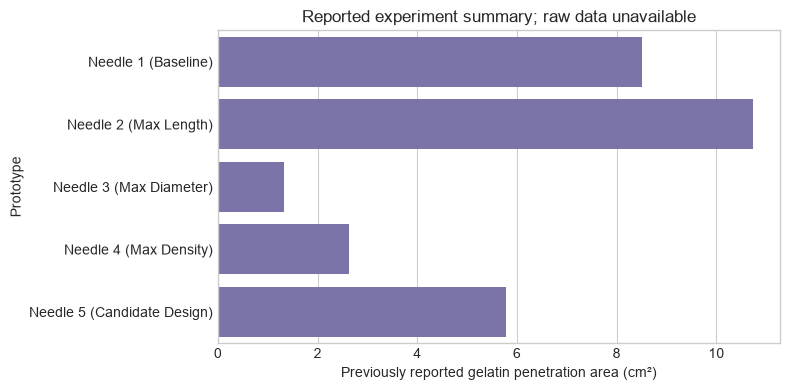

In [4]:
exp=pd.DataFrame({"Prototype":["Needle 1 (Baseline)","Needle 2 (Max Length)","Needle 3 (Max Diameter)","Needle 4 (Max Density)","Needle 5 (Candidate Design)"],"Length_um":[600,800,600,600,688],"Inner_diameter_um":[40,40,60,40,45.2],"Density_cm2":[350,350,350,500,402],"Reported_gelatin_penetration_area_cm2":[8.50,10.74,1.33,2.62,5.77],"Data_status":["Previously reported summary; raw measurements unavailable"]*5})
exp.to_csv(TAB/"experimental_validation_summary.csv",index=False,encoding="utf-8-sig"); print(exp.to_string(index=False))
plt.figure(figsize=(8,4)); sns.barplot(data=exp,x="Reported_gelatin_penetration_area_cm2",y="Prototype",color="#756bb1")
plt.xlabel("Previously reported gelatin penetration area (cm²)"); plt.ylabel("Prototype"); plt.title("Reported experiment summary; raw data unavailable")
plt.tight_layout(); plt.savefig(FIG/"experimental_validation_summary.png"); plt.show()

Model-derived designs were fabricated using 3D printing and evaluated using a gelatin-based penetration experiment. The available files do not show that a design selected by this updated ranking was tested. Detailed protocol, replication, uncertainty, and clinical performance are not established here.